# Lab 1 — Projectile Motion Solver

**Name:** Matthew Nallar  
**Date:** August 29, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
def simulate_freefall(h, dt, g=9.81):
    # Initial conditions: y position = h and starts from rest
    y, vy = h, 0.0
    t = 0.0
    # Storage lists for plotting
    t_arr, y_arr, vy_arr = [t], [y], [vy]

    # Euler integration loop
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ay = -g

        # Update velocity (Euler)
        vy = vy + ay * dt

        # Update position (Euler)
        y = y + vy * dt

        t += dt
        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)

    return np.array(t_arr), np.array(y_arr), np.array(vy_arr)

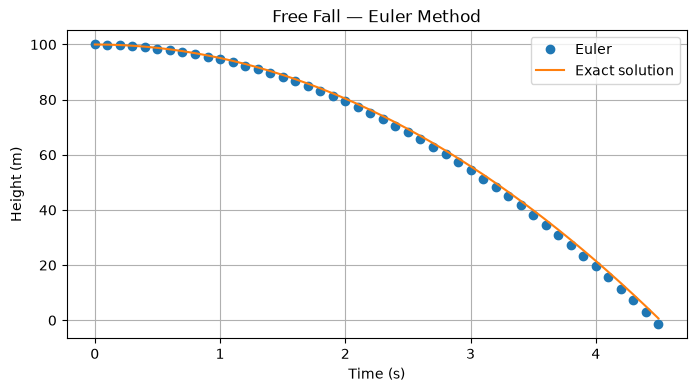

In [73]:
t, y, yv = simulate_freefall(h=100, dt=0.1)

h = 100
g = 9.81
y_exact = h - 0.5 * g * t**2

plt.figure(figsize=(8, 4))
plt.plot(t, y, 'o', label='Euler')
plt.plot(t, y_exact, '-', label='Exact solution')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall — Euler Method')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
def simulate_projectile_2d(v0=30, theta_deg=45, dt=0.01, g=9.81):
    # Initial conditions: initial velocity, angle,
    t = 0.0
    x = 0.0
    y = 0.0
    vx = 0.0
    vy = 0.0

    theta_rad = np.radians(theta_deg)
    vx, vy = v0 * np.cos(theta_rad), v0 * np.sin(theta_rad)

    # Storage lists for plotting
    t_arr, x_arr, y_arr, vx_arr, vy_arr = [t], [x], [y], [vx], [vy]

    # Euler integration loop
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g

        # Update velocity (Euler)
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Update position (Euler)
        x = x + vx * dt
        y = y + vy * dt

        t += dt
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    
    return np.array(t_arr), np.array(x_arr), np.array(y_arr), np.array(vx_arr), np.array(vy_arr)

In [93]:
# Run the projectile simulation at 45 degrees
t45, x45, y45, vx45, vy45 = simulate_projectile_2d(30, 45, 0.01)

# Calculate range and percentage error
prorange = x45.max()
rangeerror = 100 - ((prorange / 91.74) * 100)

print("Range:", prorange, "m")
print("Range error:", rangeerror, "%")

# Calculate maximum height and percentage error
maxheight = y45.max()
heighterror = 100 - ((maxheight / 22.94) * 100)

print("Maximum height:", maxheight, "m")
print("Height error:", heighterror, "%")

# Calculate flight time and percentage error
flighttime = t45.max()
flighttimeerror = 100 - ((flighttime / 4.324) * 100)

print("Flight time:", flighttime, "s")
print("Flight time error:", flighttimeerror, "%")

Range: 91.64103884177646 m
Range error: 0.1078713300888694 %
Maximum height: 22.829803420888364 m
Height error: 0.480368697086476 %
Flight time: 4.319999999999952 s
Flight time error: 0.09250693802145804 %


C:\Users\matth\AppData\Local\Temp\ipykernel_18172\320096509.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


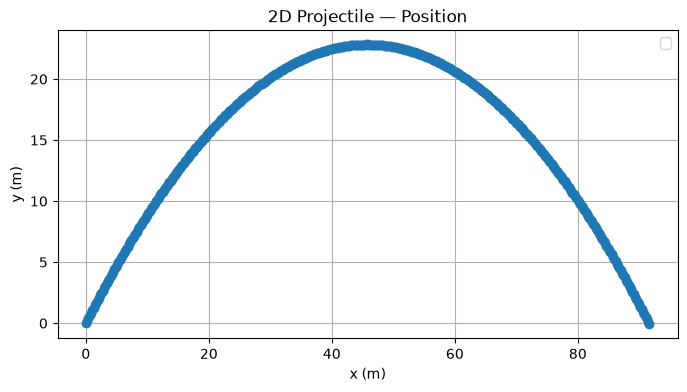

C:\Users\matth\AppData\Local\Temp\ipykernel_18172\320096509.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


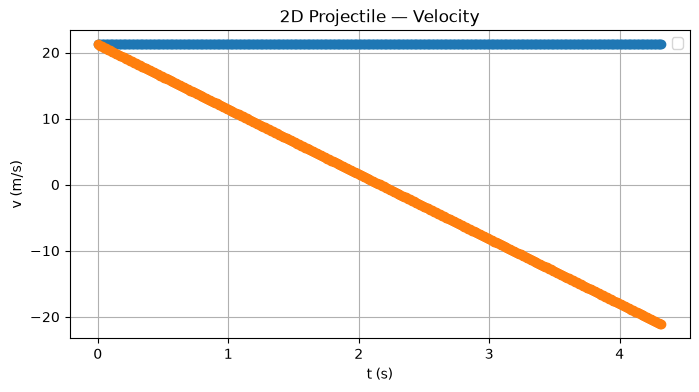

In [94]:
t, x, y, vx, vy = simulate_projectile_2d(v0=30, theta_deg=45, dt=0.01, g=9.81)

g = 9.81

plt.figure(figsize=(8, 4))
plt.plot(x, y, 'o')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('2D Projectile — Position')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, vx, 'o')
plt.plot(t, vy, 'o')
plt.xlabel('t (s)')
plt.ylabel('v (m/s)')
plt.title('2D Projectile — Velocity')
plt.legend()
plt.grid(True)
plt.show()

explain here

10 31.31688654578815 1.3571950249041935 1.0600000000000007
15 45.784884166101676 3.0340513689297497 1.5800000000000012
20 58.918727323276286 5.314768471760863 2.0899999999999994
25 70.14822271663658 8.129641729365051 2.579999999999989
30 79.24132444627622 11.392931999999965 3.049999999999979
35 86.01096465034485 15.005362908429895 3.4999999999999694
40 90.31663984372715 18.856725449568536 3.92999999999996
45 91.64103884177646 22.829803420888364 4.319999999999952
50 90.24738039999012 26.803724906952386 4.679999999999945
55 86.2085383835629 30.65752832167457 5.009999999999938
60 79.35000000000015 34.27383197972776 5.289999999999932
65 70.2391551013037 37.54273410274589 5.539999999999926
70 58.89586868067967 40.36476664966701 5.739999999999922
75 45.810970983146404 42.653975626582884 5.899999999999919
80 31.360860886647462 44.34070909700275 6.019999999999916


C:\Users\matth\AppData\Local\Temp\ipykernel_18172\2951293499.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


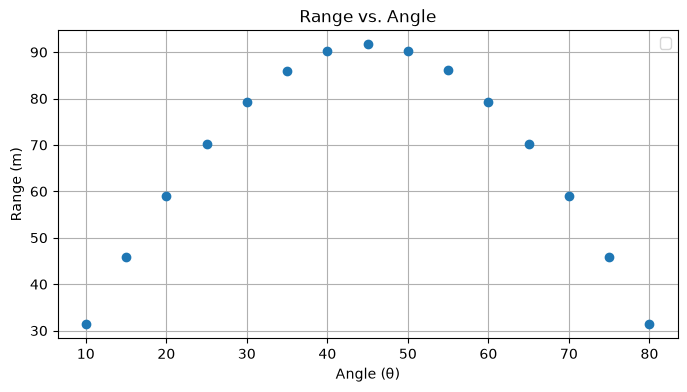

In [147]:
angles = []
ranges = []
max_heights = []
flight_times = []

for theta in range(10, 81, 5):
    t, x, y, vx, vy = simulate_projectile_2d(30, theta, 0.01)

    range_value = x.max()
    max_height = y.max()
    flight_time = t.max()

    angles.append(theta)
    ranges.append(range_value)
    max_heights.append(max_height)
    flight_times.append(flight_time)

    print(theta, range_value, max_height, flight_time)


plt.figure(figsize=(8, 4))
plt.plot(angles, ranges, 'o')
plt.xlabel('Angle (θ)')
plt.ylabel('Range (m)')
plt.title('Range vs. Angle')
plt.legend()
plt.grid(True)
plt.show()



Yes matches theory

In [132]:
def simulate_projectile_drag(v0=45, theta_deg=40, dt=0.01, g=9.81, b_over_m=0.0046):

 # Initial conditions: initial velocity, angle,
    t_drag = 0.0
    x_drag = 0.0
    y_drag = 0.0
    vx_drag = 0.0
    vy_drag = 0.0

    theta_rad = np.radians(theta_deg)
    vx_drag, vy_drag = v0 * np.cos(theta_rad), v0 * np.sin(theta_rad)

    # Storage lists for plotting
    t_drag_arr, x_drag_arr, y_drag_arr, vx_drag_arr, vy_drag_arr = [t_drag], [x_drag], [y_drag], [vx_drag], [vy_drag]

    # Euler integration loop
    while y_drag >= 0.0:
        # Compute acceleration (only gravity here)
        v_drag = np.sqrt((vx_drag**2)+(vy_drag**2))
        ax_drag = -b_over_m*v_drag*vx_drag
        ay_drag = - g - b_over_m*v_drag*vy_drag

        # Update velocity (Euler)
        vx_drag = vx_drag + ax_drag * dt
        vy_drag = vy_drag + ay_drag * dt

        # Update position (Euler)
        x_drag = x_drag + vx_drag * dt
        y_drag = y_drag + vy_drag * dt

        t_drag += dt
        t_drag_arr.append(t_drag)
        x_drag_arr.append(x_drag)
        y_drag_arr.append(y_drag)
        vx_drag_arr.append(vx_drag)
        vy_drag_arr.append(vy_drag)

    
    return np.array(t_drag_arr), np.array(x_drag_arr), np.array(y_drag_arr), np.array(vx_drag_arr), np.array(vy_drag_arr)

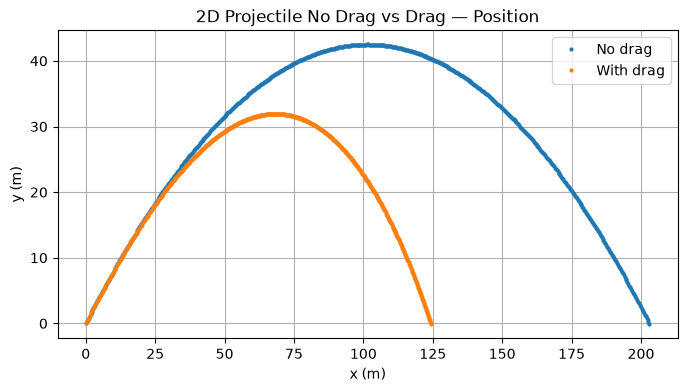

In [133]:
t, x, y, vx, vy = simulate_projectile_2d(
    v0=45, theta_deg=40, dt=0.01, g=9.81
)

# Simulate projectile with drag
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(
    v0=45, theta_deg=40, dt=0.01, g=9.81
)

# Create plot
plt.figure(figsize=(8, 4))

# Plot without drag
plt.plot(x, y, 'o', markersize=2, label='No drag')

# Plot with drag
plt.plot(x_drag, y_drag, 'o', markersize=2, label='With drag')

# Labels and formatting
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('2D Projectile No Drag vs Drag — Position')
plt.legend()
plt.grid(True)

plt.show()

In [134]:
# Run the projectile simulation at 40 degrees
t45, x45, y45, vx45, vy45 = simulate_projectile_2d(45, 40, 0.01)

# Calculate range and percentage error
prorange = x45.max()

print("Range:", prorange, "m")


# Calculate maximum height and percentage error
maxheight = y45.max()

print("Maximum height:", maxheight, "m")

# Run the projectile simulation at 40 degrees
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(45, 40, 0.01)

# Calculate range and percentage error
drag_range = x_drag.max()
drag_range_error = 100 - ((drag_range / prorange) * 100)

print("Range (drag):", drag_range, "m")


# Calculate maximum height and percentage error
drag_maxheight = y_drag.max()
drag_heighterror = 100 - ((drag_maxheight / maxheight) * 100)

print("Maximum height (drag):", drag_maxheight, "m")
print("Range reduction (drag):", drag_range_error, "%")
print("Height reduction (drag):", drag_heighterror, "%")

Range: 203.04007964868376 m
Maximum height: 42.499735761529465 m
Range (drag): 124.48049871069784 m
Maximum height (drag): 31.935160428698264 m
Range reduction (drag): 38.691661800919306 %
Height reduction (drag): 24.857978863939664 %


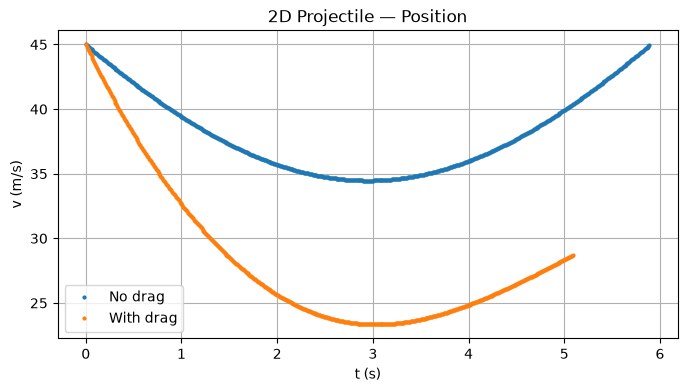

In [ ]:
t, x, y, vx, vy = simulate_projectile_2d(
    v0=45, theta_deg=40, dt=0.01, g=9.81
)

v = np.sqrt((vx**2)+(vy**2))

# Plot without drag
plt.figure(figsize=(8, 4))
plt.plot(t, v, 'o', markersize=2, label='No drag')

# Simulate projectile with drag
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(
    v0=45, theta_deg=40, dt=0.01, g=9.81
)


v_drag = np.sqrt((vx_drag**2)+(vy_drag**2))

plt.plot(t_drag, v_drag, 'o', markersize=2, label='With drag')
plt.xlabel('t (s)')
plt.ylabel('v (m/s)')
plt.title('2D Projectile — Position')
plt.legend()
plt.grid(True)
plt.show()

10 58.23271068220603 2.7767084982892416 1.5100000000000011
15 78.98866841251173 5.941979656153147 2.199999999999997
20 95.58112228839722 10.021613735227845 2.859999999999983
25 107.90308549557919 14.831218759021949 3.46999999999997
30 116.80109155702715 20.19673067951412 4.049999999999958
35 122.26096928893867 25.951730375418904 4.589999999999947
40 124.48049871069784 31.935160428698264 5.089999999999936
45 123.61979392385157 37.99066566973921 5.549999999999926
50 119.81430813304165 43.96602410917667 5.969999999999917
55 113.18470876065093 49.71195778913861 6.349999999999909
60 103.84572550188312 55.08361322081551 6.689999999999902
65 91.91577453476846 59.94087153625348 6.989999999999895
70 77.37990961432286 64.1498522776464 7.22999999999989
75 60.625942904391714 67.58587046262548 7.429999999999886
80 41.80982159893658 70.13767365563164 7.569999999999883


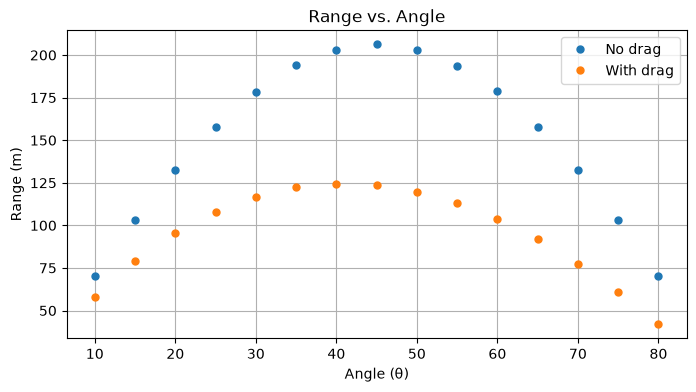

In [151]:
angles = []
ranges = []
max_heights = []
flight_times = []

for theta in range(10, 81, 5):
    t, x, y, vx, vy = simulate_projectile_2d(45, theta, 0.01)

    range_value = x.max()
    max_height = y.max()
    flight_time = t.max()

    angles.append(theta)
    ranges.append(range_value)
    max_heights.append(max_height)
    flight_times.append(flight_time)


angles_drag = []
ranges_drag = []
max_heights_drag = []
flight_times_drag = []

for theta in range(10, 81, 5):
    t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(45, theta, 0.01)

    range_value_drag = x_drag.max()
    max_height_drag = y_drag.max()
    flight_time_drag = t_drag.max()

    angles_drag.append(theta)
    ranges_drag.append(range_value_drag)
    max_heights_drag.append(max_height_drag)
    flight_times_drag.append(flight_time_drag)

    print(theta, range_value_drag, max_height_drag, flight_time_drag)


plt.figure(figsize=(8, 4))
plt.plot(angles, ranges, 'o', markersize=5, label='No drag')
plt.plot(angles_drag, ranges_drag, 'o', markersize=5, label='With drag')
plt.xlabel('Angle (θ)')
plt.ylabel('Range (m)')
plt.title('Range vs. Angle')
plt.legend()
plt.grid(True)
plt.show()





With the drag the maximum angle is now 40, contrary to 45 with no drag